# Analisi moltean/fruits datset
Questo notebook viene creato per analizzare il dataset utilizzato, controlleremo e mostreremo le varie immagini.

PS: I file *analyzer.py* e *balncer.py* fanno questo lavoro automaticamente, andando a creare ulteriori immagini in caso di sbilanciamento

In [30]:
# Import necessari

import os
import re
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset

## Controllo classi

### Numero di classi
Dal dataset utilizzato per il training otteniamo il numero di classi.

*PS*: Per via di come il creatore del dataset ha gestito le immagini/cartelle bisogna lavorare un pochino per evitare duplicati...aggiungo anche che alcune classi più specifiche verranno raggruppate e considerate insieme dal classificatore (ES: mele).

In [31]:
# Percorso del dataset di training
data_dir = 'dataset/fruits-360_dataset_original-size/fruits-360-original-size/Training'

# Rimuoviamo il numero finale dalle cartelle per evitare duplicati
def get_class_name(folder_name):
    return re.sub(r'_\d+$', '', folder_name)

# Otteniamo le classi e le cartelle corrispondenti
unique_classes = {}
for folder_name in os.listdir(data_dir):
    if os.path.isdir(os.path.join(data_dir, folder_name)):
        class_name = get_class_name(folder_name)
        if class_name not in unique_classes:
            unique_classes[class_name] = []
        unique_classes[class_name].append(folder_name)

# Mostriamo le classi uniche e le cartelle corrispondenti
for class_name, folders in unique_classes.items():
    print(f'Classe: {class_name}, Cartelle: {folders}')

Classe: apple, Cartelle: ['apple_6']
Classe: apple_braeburn, Cartelle: ['apple_braeburn_1']
Classe: apple_crimson_snow, Cartelle: ['apple_crimson_snow_1']
Classe: apple_golden, Cartelle: ['apple_golden_1', 'apple_golden_2', 'apple_golden_3']
Classe: apple_granny_smith, Cartelle: ['apple_granny_smith_1']
Classe: apple_hit, Cartelle: ['apple_hit_1']
Classe: apple_pink_lady, Cartelle: ['apple_pink_lady_1']
Classe: apple_red, Cartelle: ['apple_red_1', 'apple_red_2', 'apple_red_3']
Classe: apple_red_delicios, Cartelle: ['apple_red_delicios_1']
Classe: apple_red_yellow, Cartelle: ['apple_red_yellow_1']
Classe: apple_rotten, Cartelle: ['apple_rotten_1']
Classe: cabbage_white, Cartelle: ['cabbage_white_1']
Classe: carrot, Cartelle: ['carrot_1']
Classe: cucumber, Cartelle: ['cucumber_1', 'cucumber_3']
Classe: eggplant_long, Cartelle: ['eggplant_long_1']
Classe: pear, Cartelle: ['pear_1', 'pear_3']
Classe: zucchini, Cartelle: ['zucchini_1']
Classe: zucchini_dark, Cartelle: ['zucchini_dark_1']


### Numero di immagini per ogni classe
Ora controlliamo quante immagini sono presenti per ogni classe

In [32]:
# Calcoliamo il numero di immagini per classe unica
class_counts = {}
for class_name, folders in unique_classes.items():
    total_images = 0
    for folder_name in folders:
        class_path = os.path.join(data_dir, folder_name)
        image_files = [f for f in os.listdir(class_path) if 'balImg_' not in f]  # escludiamo le immagini create dal balancer
        total_images += len(image_files)
    class_counts[class_name] = total_images
    print(f'{class_name}: {total_images}')

apple: 315
apple_braeburn: 320
apple_crimson_snow: 318
apple_golden: 932
apple_granny_smith: 320
apple_hit: 468
apple_pink_lady: 313
apple_red: 908
apple_red_delicios: 300
apple_red_yellow: 308
apple_rotten: 319
cabbage_white: 96
carrot: 101
cucumber: 263
eggplant_long: 160
pear: 470
zucchini: 160
zucchini_dark: 160


### Distribuzione delle classi

Tramite la libreria **matplot** mostriamo tramite grafico la distribuzione delle classi

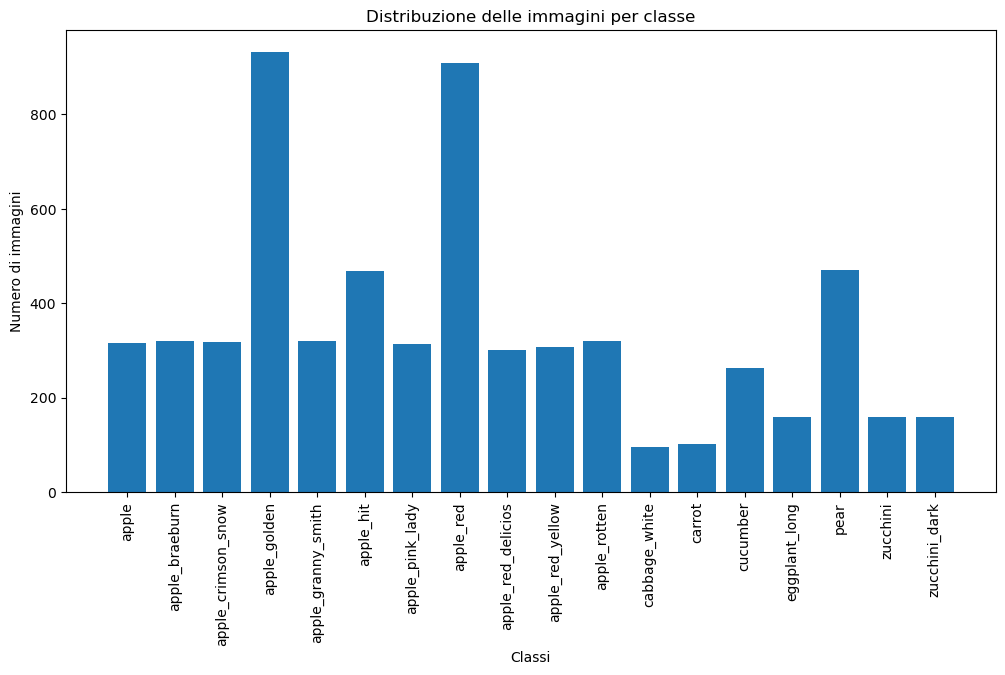

In [33]:
# Creiamo un grafico a barre per visualizzare la distribuzione delle immagini per classe
plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.xlabel('Classi')
plt.ylabel('Numero di immagini')
plt.title('Distribuzione delle immagini per classe')
plt.show()

## Visualizzazione immagini

Di seguito alcuni esempi delle immagini che il dataset fornisce...

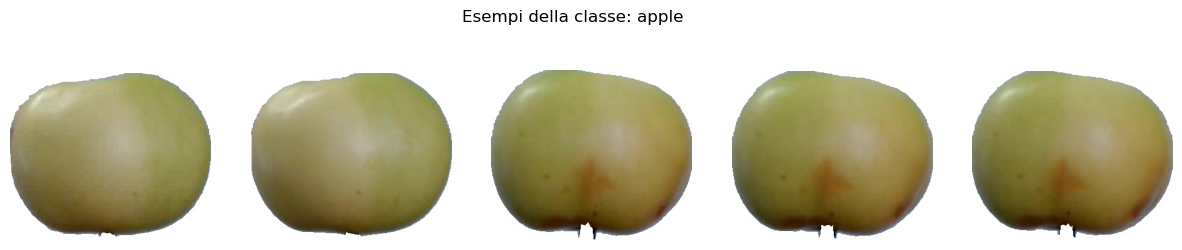

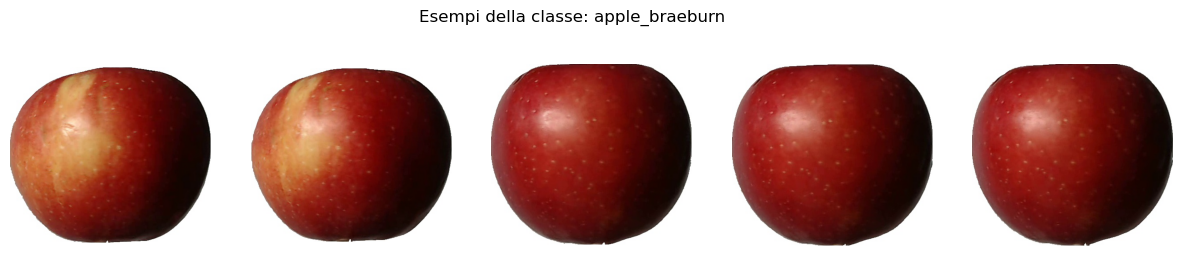

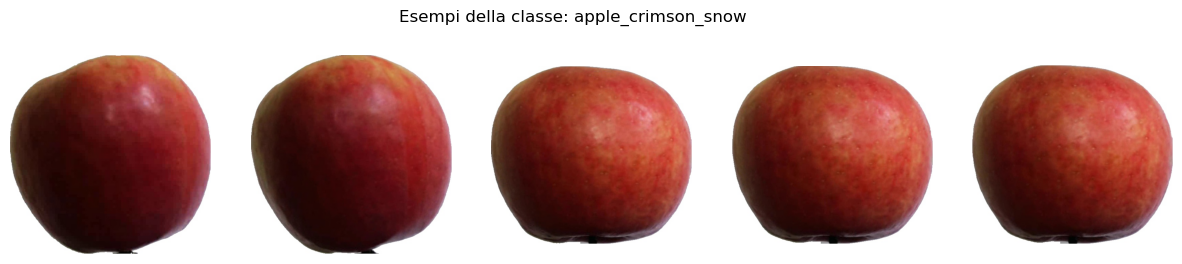

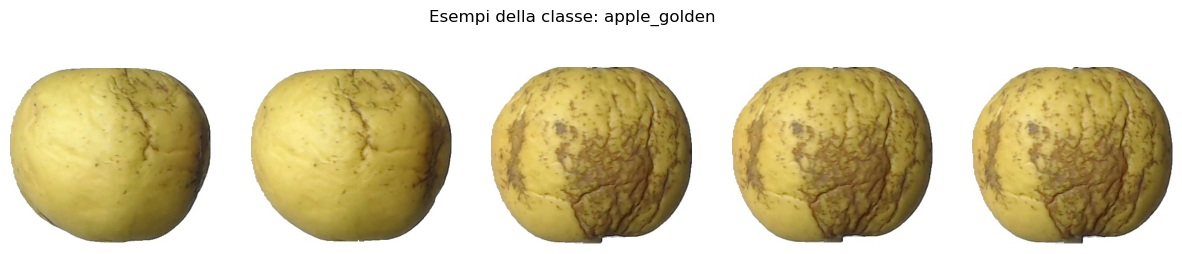

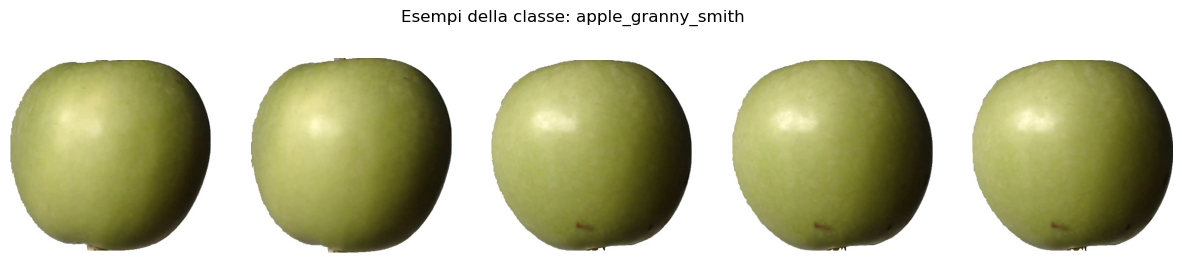

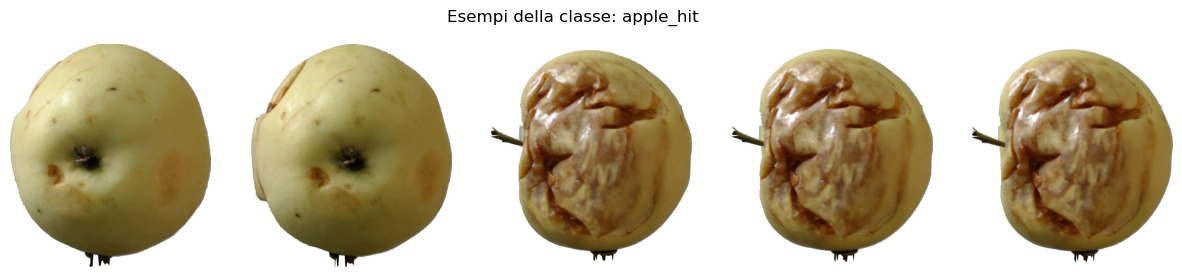

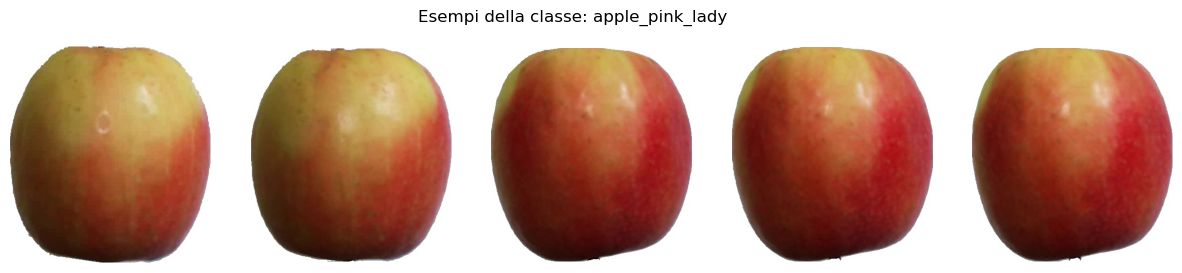

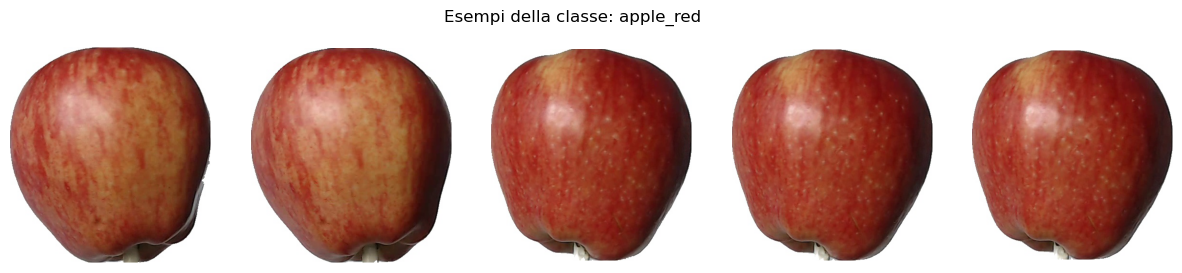

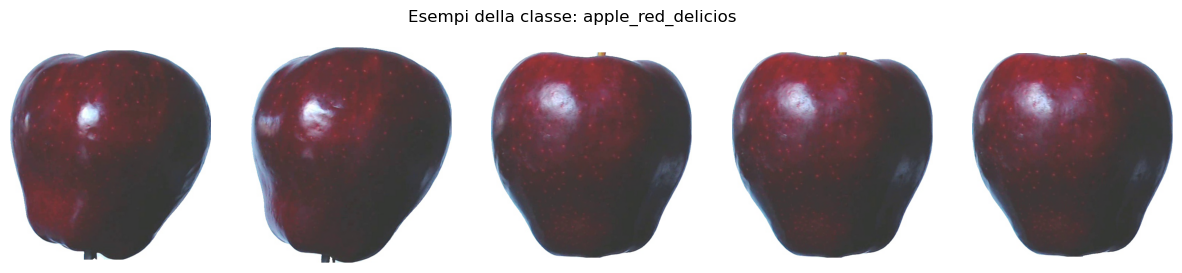

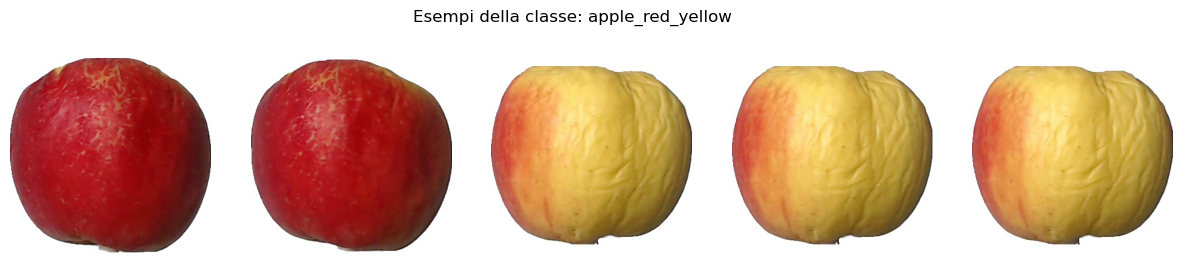

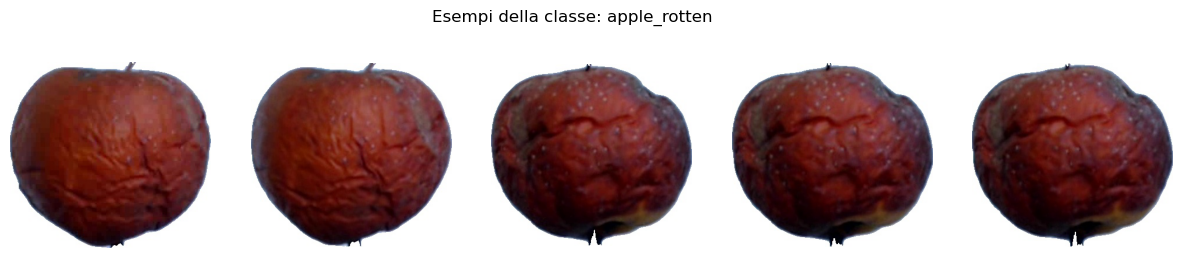

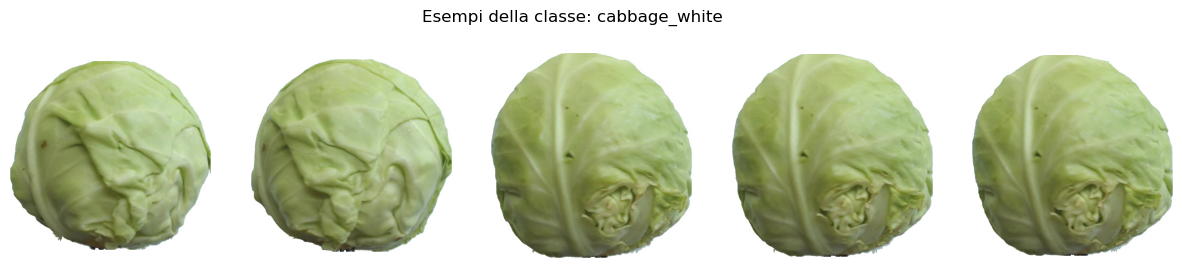

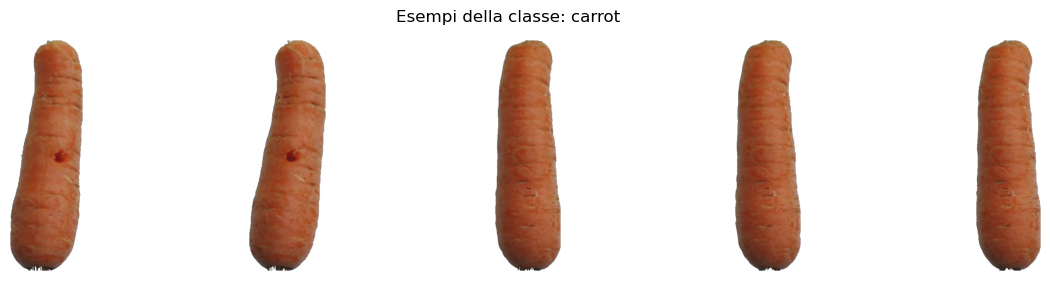

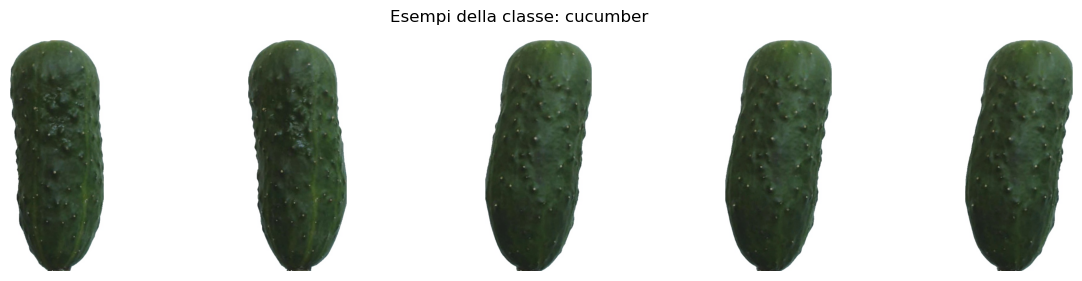

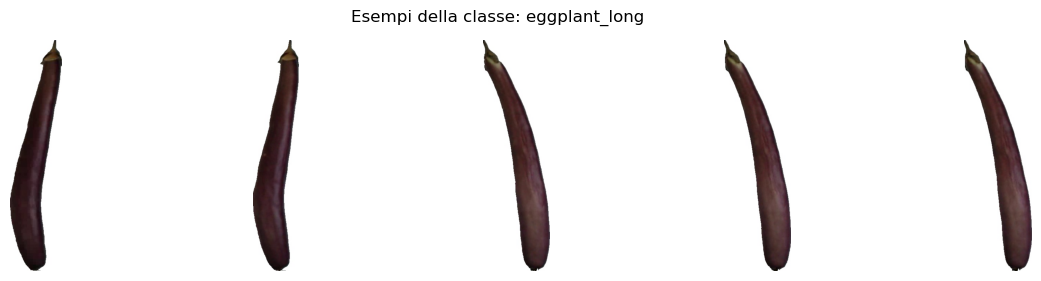

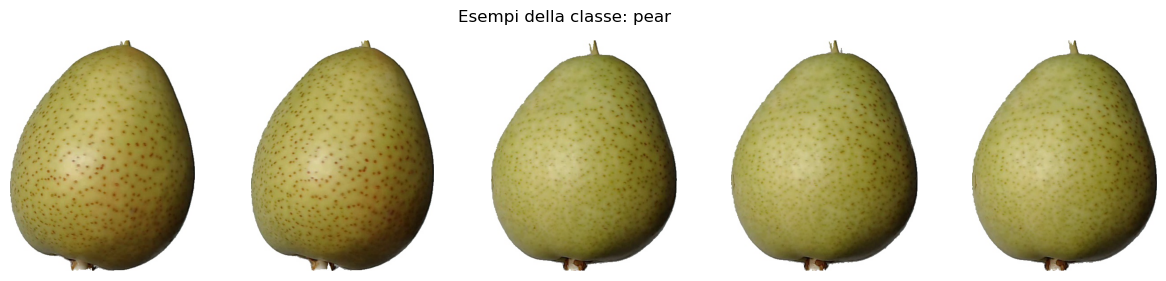

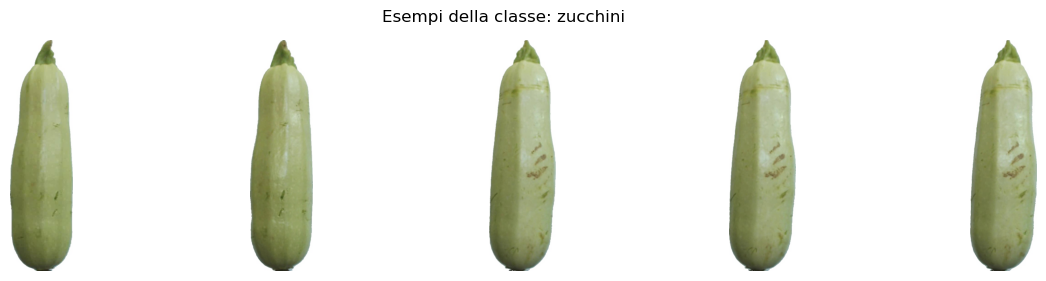

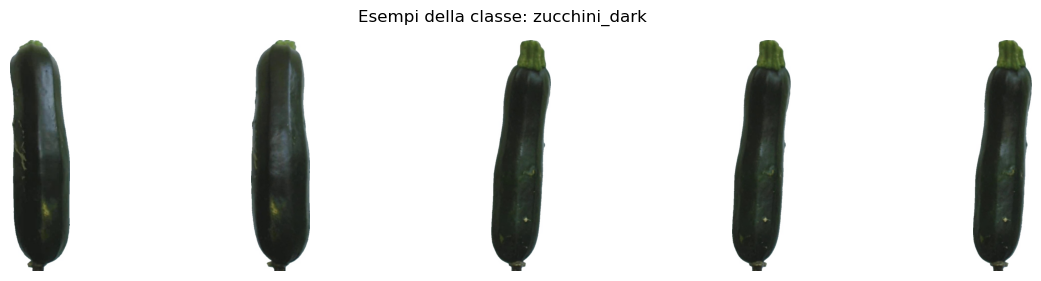

In [34]:
# Mostriamo alcune immagini di esempio per ogni classe
N = 5  # Numero di immagini da visualizzare per classe
for class_name, folders in unique_classes.items():
    image_files = []
    for folder_name in folders:
        class_path = os.path.join(data_dir, folder_name)
        image_files.extend([os.path.join(class_path, f) for f in os.listdir(class_path) if 'balImg_' not in f])
    
    # Selezioniamo N immagini casuali dalla lista
    sample_images = image_files[:N]
    
    plt.figure(figsize=(15, 3))
    for i, img_path in enumerate(sample_images):
        img = Image.open(img_path)
        plt.subplot(1, N, i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(f'Esempi della classe: {class_name}')
    plt.show()